# CIFAR-10 `p4munet` Large Inference

This notebook loads the trained `cifar10_p4munet_large_last.pt` checkpoint and generates CIFAR-10 samples with the same flow-matching sampling loop used in training.

The checkpoint includes both the training args and an EMA copy of the model weights. By default, this notebook uses the EMA weights for inference.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.pyplot as plt
import torch


def find_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        if (candidate / "scripts" / "train_flow_matching.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.train_flow_matching import (  # noqa: E402
    DATASET_SPECS,
    build_model,
    generate_samples,
    resolve_amp_dtype,
    resolve_device,
    save_image_grid,
    set_seed,
)


CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "cifar10_flow_matching" / "cifar10_p4munet_large_last.pt"
USE_EMA_WEIGHTS = True
DEVICE = None  # Set to "cpu", "cuda", or "cuda:0" to override auto-selection.
SEED = 0
NUM_SAMPLES = 16
NUM_SAMPLE_STEPS = 30
SAMPLE_BATCH_SIZE = 8
OUTPUT_PATH = PROJECT_ROOT / "samples" / "flow_matching" / "cifar10_p4munet_large" / "notebook_inference.png"

assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"
print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Project root: /workspace/gcnn
Checkpoint: /workspace/gcnn/checkpoints/cifar10_flow_matching/cifar10_p4munet_large_last.pt


In [2]:
set_seed(SEED)

device = resolve_device(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
args = SimpleNamespace(**checkpoint["args"])
model = build_model(args).to(device)

state_dict_name = "ema_model_state_dict" if USE_EMA_WEIGHTS and checkpoint.get("ema_model_state_dict") is not None else "model_state_dict"
model.load_state_dict(checkpoint[state_dict_name])
model.eval()

amp_dtype = resolve_amp_dtype(args, device) if getattr(args, "amp", False) else None

print(f"Using device: {device}")
print(f"Loaded weights: {state_dict_name}")
print(f"Model family: {args.model}")
print(f"Model size: {getattr(args, 'model_size', 'unknown')}")
print(f"Channel dims: {args.channel_dims}")
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"Best eval loss: {checkpoint['best_eval_loss']:.6f}")

Using device: cuda
Loaded weights: ema_model_state_dict
Model family: p4munet
Model size: large
Channel dims: [23, 45, 91]
Checkpoint epoch: 500
Best eval loss: 0.177869


In [3]:
samples = generate_samples(
    model,
    num_samples=NUM_SAMPLES,
    image_size=DATASET_SPECS["image_size"],
    in_channels=DATASET_SPECS["in_channels"],
    device=device,
    amp_dtype=amp_dtype,
    num_steps=NUM_SAMPLE_STEPS,
    batch_size=SAMPLE_BATCH_SIZE,
)

print(f"Generated samples tensor: {tuple(samples.shape)}")
samples

Generated samples tensor: (16, 3, 32, 32)


tensor([[[[0.0846, 0.0846, 0.0945,  ..., 0.5604, 0.6182, 0.4159],
          [0.0875, 0.0918, 0.0997,  ..., 0.5966, 0.6321, 0.4219],
          [0.0892, 0.0907, 0.0926,  ..., 0.6131, 0.6289, 0.4231],
          ...,
          [0.2748, 0.2720, 0.2669,  ..., 0.3944, 0.3880, 0.3884],
          [0.2832, 0.2864, 0.2869,  ..., 0.4084, 0.3832, 0.3787],
          [0.3360, 0.3409, 0.3309,  ..., 0.4230, 0.4149, 0.4023]],

         [[0.0958, 0.0962, 0.1076,  ..., 0.5253, 0.5872, 0.4027],
          [0.0965, 0.1015, 0.1097,  ..., 0.5622, 0.6014, 0.4168],
          [0.0969, 0.0975, 0.0997,  ..., 0.5791, 0.5986, 0.4149],
          ...,
          [0.2494, 0.2457, 0.2408,  ..., 0.3644, 0.3632, 0.3608],
          [0.2546, 0.2586, 0.2606,  ..., 0.3771, 0.3568, 0.3496],
          [0.3059, 0.3111, 0.3009,  ..., 0.3924, 0.3883, 0.3731]],

         [[0.0986, 0.0990, 0.1032,  ..., 0.4159, 0.4686, 0.3066],
          [0.1018, 0.1035, 0.1048,  ..., 0.4465, 0.4790, 0.3228],
          [0.0991, 0.0971, 0.0966,  ..., 0

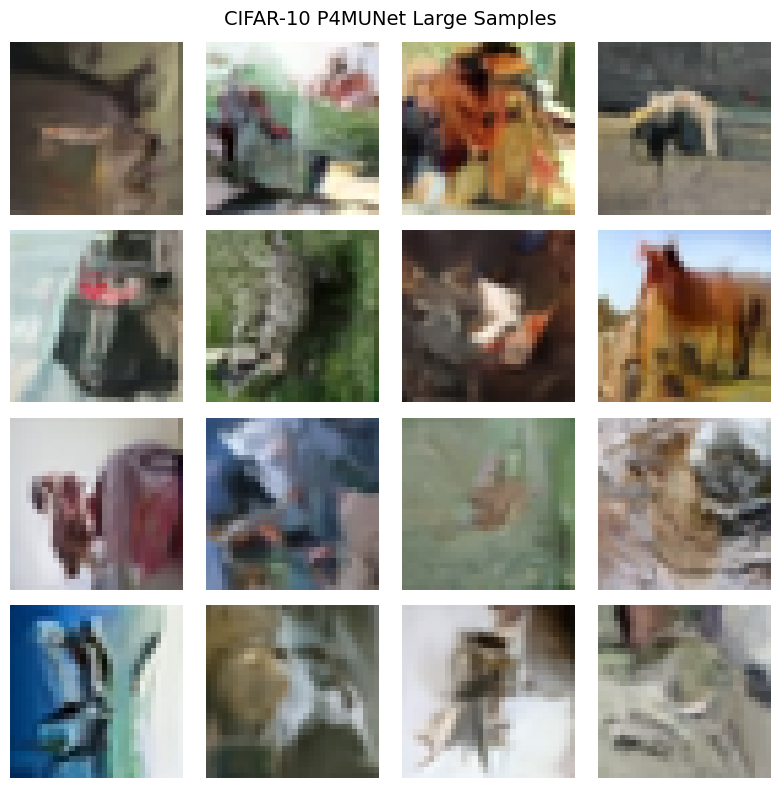

In [4]:
num_images = samples.shape[0]
grid_cols = int(num_images**0.5)
while num_images % grid_cols != 0:
    grid_cols -= 1
grid_rows = (num_images + grid_cols - 1) // grid_cols

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 2, grid_rows * 2))
axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

for ax, image in zip(axes, samples):
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.axis("off")

for ax in axes[num_images:]:
    ax.axis("off")

fig.suptitle("CIFAR-10 P4MUNet Large Samples", fontsize=14)
fig.tight_layout()

In [5]:
save_image_grid(samples, OUTPUT_PATH)
print(f"Saved sample grid to: {OUTPUT_PATH}")

Saved sample grid to: /workspace/gcnn/samples/flow_matching/cifar10_p4munet_large/notebook_inference.png


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for idx, (label, noise, output, canonical) in enumerate(
    zip(ROTATION_LABELS, rotated_noises, rotated_outputs, canonical_outputs)
):
    noise_image = denormalize_cifar_images(noise)[0].permute(1, 2, 0).numpy()
    output_image = output[0].permute(1, 2, 0).numpy()
    canonical_image = canonical[0].permute(1, 2, 0).numpy()

    axes[0, idx].imshow(noise_image)
    axes[0, idx].set_title(f"Noise {label}")
    axes[0, idx].axis("off")

    axes[1, idx].imshow(output_image)
    axes[1, idx].set_title(f"Generated {label}")
    axes[1, idx].axis("off")

    axes[2, idx].imshow(canonical_image)
    axes[2, idx].set_title(f"Rotated Back {label}")
    axes[2, idx].axis("off")

fig.suptitle("Equivariant generation from rotated initial noise", fontsize=14)
fig.tight_layout()